In [2]:
# test-4-figure.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
%matplotlib inline

In [3]:
# specifying the path to the csv file that needs to be imported (the overlap.csv)
input_file_path = "/Volumes/KINGSTON/code/phd/image-analysis/synapse-counting/VCAM1/VCAM1-LacZ_VGLUT1-PSD95_output_data/results.csv"

df = pd.read_csv(input_file_path)
print(df.head(3))

   Unnamed: 0                                       img_filename  overlap_um2  \
0           0  CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_LacZ-gR...    76.315746   
1           1  CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_LacZ-gR...   128.030053   
2           2  CRISPR-Exp4_IHC-Exp2_Brain-4_section-1_LacZ-gR...   109.555546   

   overlap_um2_rot  pearson_cor  pvalue  pearson_cor_rot    pvalue_rot  \
0        34.475069     0.179783     0.0        -0.005714  3.711006e-09   
1        85.664599     0.133504     0.0         0.003024  1.803743e-03   
2        66.675539     0.144536     0.0         0.008416  3.777611e-18   

   overlap_coeff  overlap_coeff_rot  ...  presynapse_image_mfi  \
0       0.191092           0.077531  ...            352.827426   
1       0.210939           0.138418  ...           1061.303937   
2       0.214162           0.132189  ...            596.027361   

   postsynapse_image_mfi  pre_puncta_density_per_100_um2  \
0             198.977408                       89.936

In [10]:
# transforming the df into the right format

# dropping the unneccesarry columns (vlgut1 threshold and psd95_threshold)
df_drop = df.drop(['presynapse_threshold', 'postsynapse_threshold'], axis=1)

# adding an extra element to the first column so that each observation is unique
df_drop["img_filename"] = df_drop["img_filename"] + "_" + (df_drop.groupby("img_filename").cumcount() + 1).astype(str)

# pivoting the df into longer format
df_melted = pd.melt(df_drop, id_vars = ["img_filename"], value_vars=["overlap_um2", "overlap_um2_rot"],
                    var_name="condition", value_name="overlap (um2)")

# replacing the names for the condition
df_melted["condition"] = df_melted["condition"].apply(lambda x: "rotated" if "overlap_um2_rot" in x else "actual")

# sorting the df based on the first column
df_sorted = df_melted.sort_values('img_filename')

# have column that takes the hippocampal layer
df_sorted['hippocampal layer'] = df_sorted['img_filename'].apply(lambda x: ' '.join(x.split('_')[-3:-1]))


df_sorted.head(5)

,img_filename,condition,overlap (um2),hippocampal layer
48,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,113.571447,CA1 SLM
224,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,rotated,69.011475,CA1 SLM
49,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,147.644414,CA1 SO
225,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,rotated,109.357903,CA1 SO
50,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,129.185242,CA1 SR


In [627]:
import numpy as np
from matplotlib.patches import PathPatch

def adjust_box_widths(g, fac):
    """
    Adjust the widths of a seaborn-generated boxplot.
    """

    # iterating through Axes instances
    for ax in g.axes:

        # iterating through axes artists:
        for c in ax.get_children():

            # searching for PathPatches
            if isinstance(c, PathPatch):
                # getting current width of box:
                p = c.get_path()
                verts = p.vertices
                verts_sub = verts[:-1]
                xmin = np.min(verts_sub[:, 0])
                xmax = np.max(verts_sub[:, 0])
                xmid = 0.5*(xmin+xmax)
                xhalf = 0.5*(xmax - xmin)

                # setting new width of box
                xmin_new = xmid-fac*xhalf
                xmax_new = xmid+fac*xhalf
                verts_sub[verts_sub[:, 0] == xmin, 0] = xmin_new
                verts_sub[verts_sub[:, 0] == xmax, 0] = xmax_new

                # setting new width of median line
                for l in ax.lines:
                    if np.all(l.get_xdata() == [xmin, xmax]):
                        l.set_xdata([xmin_new, xmax_new])

/var/folders/p5/hzbdgkws2lvg79nyhlq_g_sm0000gn/T/ipykernel_54954/402412410.py:38: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(


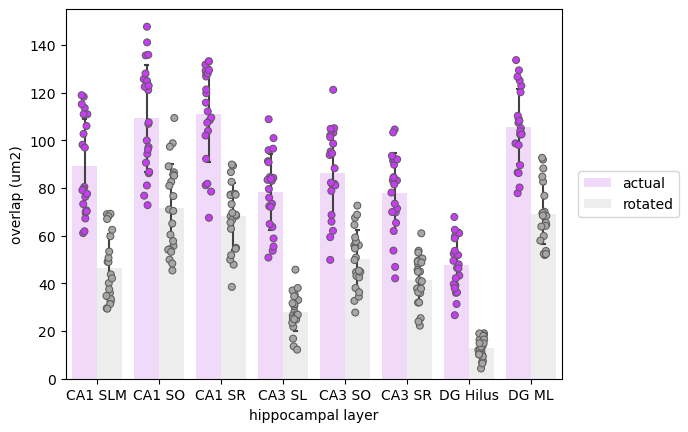

In [8]:
# #creating the plot
# fig = plt.figure(figsize=(5, 5))
# p = sns.stripplot(y="overlap (um2)", x="hippocampal layer", hue = "condition",
#                         data = df_sorted,
#                         jitter = False,
#                         dodge = 0.05,
#                         marker = "o",
#                         alpha = 0.5)

# sns.pointplot(y="overlap (um2)", x="hippocampal layer", hue = "condition",  
#               data=df_sorted, dodge=0.2, join=False, palette="dark",  
#               markers="_", scale=3, ax=p)

# sns.swarmplot(data=df_sorted, x="hippocampal layer", y="overlap (um2)", hue="condition", dodge=True)

# box = sns.boxplot(y="overlap (um2)", 
#             x="hippocampal layer", 
#             hue = "condition",
#             showmeans = True, 
#             meanline=True,
#             linewidth = 0.75,
#             meanprops={'color': 'k', 'ls': 'solid', 'lw': 1},
#             width = 0.6,
#             medianprops={'visible': False},
#             whiskerprops={'visible': False},
#             showfliers=False,
#             showbox=False,
#             showcaps=False,
#             zorder=0,
#             data=df_sorted, 
#             palette="dark",  
#             ax=p)

# adjust_box_widths(fig, 10)


# Draw the bar chart
ax = sns.barplot(
    data=df_sorted, 
    x="hippocampal layer", 
    y="overlap (um2)", 
    hue="condition",  
    errorbar="sd",
    palette=['#c92ffa', '#a6a7a5'],
    errwidth=1.5,
    capsize = 0.1, 
    alpha=0.2)


# Get the legend from just the bar chart
handles, labels = ax.get_legend_handles_labels()

# Draw the stripplot
sns.stripplot(
    data=df_sorted, 
    x="hippocampal layer", 
    y="overlap (um2)", 
    hue="condition", 
    dodge=True, 
    edgecolor=None, 
    linewidth=.75,
    ax=ax,
    palette=['#cb3afa', '#a6a7a5']
)

# Remove the old legend
ax.legend_.remove()

# Add just the bar chart legend back
ax.legend(
    handles,
    labels,
    loc=7,
    bbox_to_anchor=(1.25, .5),
)



In [629]:
# # exporting the plot as png
# output_folder = "/mnt/d/code/phd/image-analysis/synapse-counting/output_data/"

# output_file = os.path.join(output_folder, "dotplot.png")
# plot = p.get_figure()
# plot.savefig(output_file, dpi = 300)

In [630]:
# 

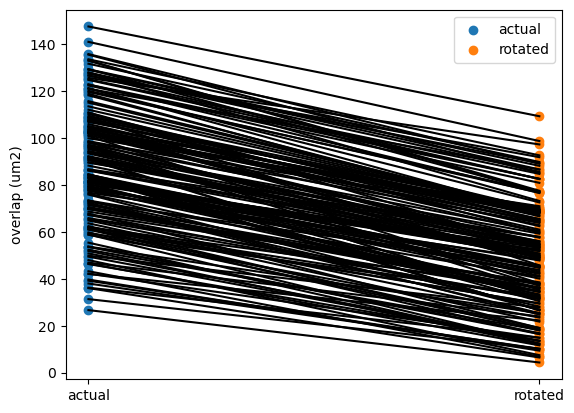

In [9]:
# Separate the data for actual and rotated conditions
actual_data = df_sorted[df_sorted["condition"] == "actual"]
rotated_data = df_sorted[df_sorted["condition"] == "rotated"]

# Create the plot
plt.scatter(np.zeros(len(actual_data)), actual_data["overlap (um2)"], label="actual")
plt.scatter(np.ones(len(rotated_data)), rotated_data["overlap (um2)"], label="rotated")

# Plot the lines connecting points
for i in range(len(actual_data)):
    plt.plot([0, 1], [actual_data.iloc[i]["overlap (um2)"], rotated_data.iloc[i]["overlap (um2)"]], c='k')

plt.xticks([0, 1], ['actual', 'rotated'])
plt.ylabel("overlap (um2)")
plt.legend()

plt.show()

In [15]:
df_sorted

,img_filename,condition,overlap (um2),hippocampal layer
48,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,113.571447,CA1 SLM
224,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,rotated,69.011475,CA1 SLM
49,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,147.644414,CA1 SO
225,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,rotated,109.357903,CA1 SO
50,CRISPR-Exp4_IHC-Exp2_Brain-4-2_section-1_LacZ-...,actual,129.185242,CA1 SR
...,...,...,...,...
169,CRISPR-Exp5_IHC-Exp2_Brain-7_section-2_VCAM1-g...,actual,46.895907,CA3 SR
170,CRISPR-Exp5_IHC-Exp2_Brain-7_section-2_VCAM1-g...,actual,42.191664,DG Hilus
346,CRISPR-Exp5_IHC-Exp2_Brain-7_section-2_VCAM1-g...,rotated,14.887968,DG Hilus
347,CRISPR-Exp5_IHC-Exp2_Brain-7_section-2_VCAM1-g...,rotated,68.435584,DG ML
